<a href="https://colab.research.google.com/github/saifalisayyed14/Palo-Altos-Network/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Palo Alto Networks

### Business Objective
The primary objective of this project is to equip HR with early warning diagnostics to detect engagement and well being signals before employees decide to leave. It aims to create a unified engagement health index and provide clear visibility into burnout-prone employee groups.

In [1]:
# Loading necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# Loading dataset
df = pd.read_csv('/content/Palo Alto Networks.csv')

In [6]:
# Shape of dataset
df.shape

(1470, 31)

In [7]:
# head of dataset
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2


In [8]:
# Getting the info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   int64 
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EnvironmentSatisfaction   1470 non-null   int64 
 9   Gender                    1470 non-null   object
 10  HourlyRate                1470 non-null   int64 
 11  JobInvolvement            1470 non-null   int64 
 12  JobLevel                  1470 non-null   int64 
 13  JobRole                   1470 non-null   object
 14  JobSatisfaction         

In [9]:
# Describe the dataset
df.describe()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,0.161224,802.485714,9.192517,2.912925,2.721769,65.891156,2.729932,2.063946,2.728571,...,3.153741,2.712245,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,0.367863,403.509100,8.106864,1.024165,1.093082,20.329428,0.711561,1.106940,1.102846,...,0.360824,1.081209,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,0.000000,102.000000,1.000000,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,...,3.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,0.000000,465.000000,2.000000,2.000000,2.000000,48.000000,2.000000,1.000000,2.000000,...,3.000000,2.000000,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,0.000000,802.000000,7.000000,3.000000,3.000000,66.000000,3.000000,2.000000,3.000000,...,3.000000,3.000000,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,0.000000,1157.000000,14.000000,4.000000,4.000000,83.750000,3.000000,3.000000,4.000000,...,3.000000,4.000000,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1.000000,1499.000000,29.000000,5.000000,4.000000,100.000000,4.000000,5.000000,4.000000,...,4.000000,4.000000,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [10]:
# Isolate numerical columns for statistical calculations
num_cols = df.select_dtypes(include=[np.number]).columns

In [11]:
# First Moment: Mean (Central Tendency)
mean_values = df[num_cols].mean()

In [12]:
# Second Moment: Variance & Standard Deviation
variance_values = df[num_cols].var()
std_dev_values = df[num_cols].std()

In [13]:
# Third Moment: Skewness
skewness_values = df[num_cols].skew()

In [14]:
moments_summary = pd.DataFrame({
    'Mean (1st)': mean_values,
    'Variance (2nd)': variance_values,
    'Std Dev': std_dev_values,
    'Skewness (3rd)': skewness_values
})

display(moments_summary)

,Mean (1st),Variance (2nd),Std Dev,Skewness (3rd)
Age,36.923810,8.345505e+01,9.135373,0.413286
Attrition,0.161224,1.353232e-01,0.367863,1.844366
DailyRate,802.485714,1.628196e+05,403.509100,-0.003519
DistanceFromHome,9.192517,6.572125e+01,8.106864,0.958118
Education,2.912925,1.048914e+00,1.024165,-0.289681
EnvironmentSatisfaction,2.721769,1.194829e+00,1.093082,-0.321654
HourlyRate,65.891156,4.132856e+02,20.329428,-0.032311
JobInvolvement,2.729932,5.063193e-01,0.711561,-0.498419
JobLevel,2.063946,1.225316e+00,1.106940,1.025401
JobSatisfaction,2.728571,1.216270e+00,1.102846,-0.329672


In [15]:
# Checking null values
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EnvironmentSatisfaction,0
Gender,0


In [16]:
# Checking duplicate values
df.duplicated().sum()

np.int64(0)

In [17]:
# check if any numeric columns have a standard deviation of 0
cols_to_drop = [col for col in df.columns if df[col].nunique() == 1]
df = df.drop(columns=cols_to_drop)

In [18]:
# Validating Ordinal Scales

ordinal_columns = [
    'EnvironmentSatisfaction',
    'JobInvolvement',
    'JobSatisfaction',
    'RelationshipSatisfaction',
    'WorkLifeBalance'
]
for col in ordinal_columns:
    if col in df.columns:
        min_val = df[col].min()
        max_val = df[col].max()
        print(f"{col}: Min = {min_val}, Max = {max_val}")

        df[col] = df[col].clip(lower=1, upper=4)

EnvironmentSatisfaction: Min = 1, Max = 4
JobInvolvement: Min = 1, Max = 4
JobSatisfaction: Min = 1, Max = 4
RelationshipSatisfaction: Min = 1, Max = 4
WorkLifeBalance: Min = 1, Max = 4


In [20]:
# Isolate categorical columns
cat_cols = df.select_dtypes(include=['object']).columns

print("Categorical Data Overview -")
display(df[cat_cols].describe())

print("\nUnivariate Analysis: Percentage Breakdown -")
# Loop through categorical columns to see the exact distribution percentages
for col in cat_cols:
    print(f"\n{col} Distribution:")
    # normalize=True gives us the proportion, multiplying by 100 gives percentages
    print((df[col].value_counts(normalize=True) * 100).round(2))

Categorical Data Overview -


,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,OverTime
count,1470,1470,1470,1470,1470,1470,1470
unique,3,3,6,2,9,3,2
top,Travel_Rarely,Research & Development,Life Sciences,Male,Sales Executive,Married,No
freq,1043,961,606,882,326,673,1054



Univariate Analysis: Percentage Breakdown -

BusinessTravel Distribution:
BusinessTravel
Travel_Rarely        70.95
Travel_Frequently    18.84
Non-Travel           10.20
Name: proportion, dtype: float64

Department Distribution:
Department
Research & Development    65.37
Sales                     30.34
Human Resources            4.29
Name: proportion, dtype: float64

EducationField Distribution:
EducationField
Life Sciences       41.22
Medical             31.56
Marketing           10.82
Technical Degree     8.98
Other                5.58
Human Resources      1.84
Name: proportion, dtype: float64

Gender Distribution:
Gender
Male      60.0
Female    40.0
Name: proportion, dtype: float64

JobRole Distribution:
JobRole
Sales Executive              22.18
Research Scientist           19.86
Laboratory Technician        17.62
Manufacturing Director        9.86
Healthcare Representative     8.91
Manager                       6.94
Sales Representative          5.65
Research Director           

### EDA Observations & Baseline Distributions

Workload & Stressors:
Overtime: Fairly high at approx 28%. This is a strong candidate for the burnout risk score.
Travel: Most travel rarely (71%), but nearly 19% travel frequently.

Organizational Structure:
Departments: Massively skewed toward R&D (65%) and Sales (30%). HR is only 4%.

Demographics:
Gender: 60% Male / 40% Female.
Marital Status: Mostly Married (46%) and Single (32%).

The Primary Burnout Pool: With over a quarter of the company (28.3%) working overtime and nearly a fifth (18.84%) traveling frequently, there is a substantial, highly visible segment of the population primed for the Burnout Risk Score evaluation.

Mandatory Dashboard Filtering: Because R&D and Sales make up over 95% of the company, an organization-wide average engagement score will inherently silence the HR department's data. Building robust Department & role filters into the final Streamlit web application is structurally mandatory to ensure all managers receive accurate insights.

In [21]:
# Set a cool, professional theme for our visualizations
sns.set_theme(style="darkgrid", palette="deep")

In [22]:
df.columns = df.columns.str.strip()


In [23]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   int64 
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EnvironmentSatisfaction   1470 non-null   int64 
 9   Gender                    1470 non-null   object
 10  HourlyRate                1470 non-null   int64 
 11  JobInvolvement            1470 non-null   int64 
 12  JobLevel                  1470 non-null   int64 
 13  JobRole                   1470 non-null   object
 14  JobSatisfaction         

In [25]:
df.columns = df.columns.str.strip()

In [27]:
# Pulls a quick summary of the text columns
categorical_summary = df.describe(include=['object', 'string'])
print(categorical_summary)

       BusinessTravel              Department EducationField Gender  \
count            1470                    1470           1470   1470   
unique              3                       3              6      2   
top     Travel_Rarely  Research & Development  Life Sciences   Male   
freq             1043                     961            606    882   

                JobRole MaritalStatus OverTime  
count              1470          1470     1470  
unique                9             3        2  
top     Sales Executive       Married       No  
freq                326           673     1054  


In [28]:
# 1. FEATURE ENGINEERING: Create the EngagementIndex
# Calculate this as the average of JobInvolvement and JobSatisfaction
df['EngagementIndex'] = (df['JobInvolvement'] + df['JobSatisfaction']) / 2

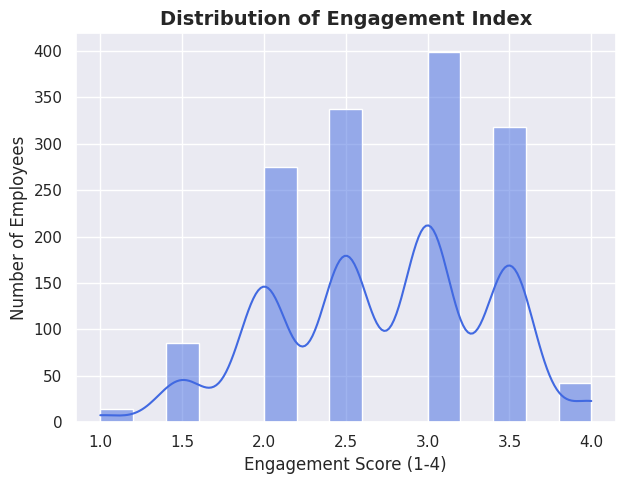

In [29]:
# 2. VISUALIZATION: Run your plotting code
plt.figure(figsize=(12, 5))

# Plot A: Distribution of Engagement Index
plt.subplot(1, 2, 1)
sns.histplot(df['EngagementIndex'], bins=15, kde=True, color='royalblue')
plt.title('Distribution of Engagement Index', fontsize=14, fontweight='bold')
plt.xlabel('Engagement Score (1-4)')
plt.ylabel('Number of Employees')

plt.tight_layout()
plt.show()

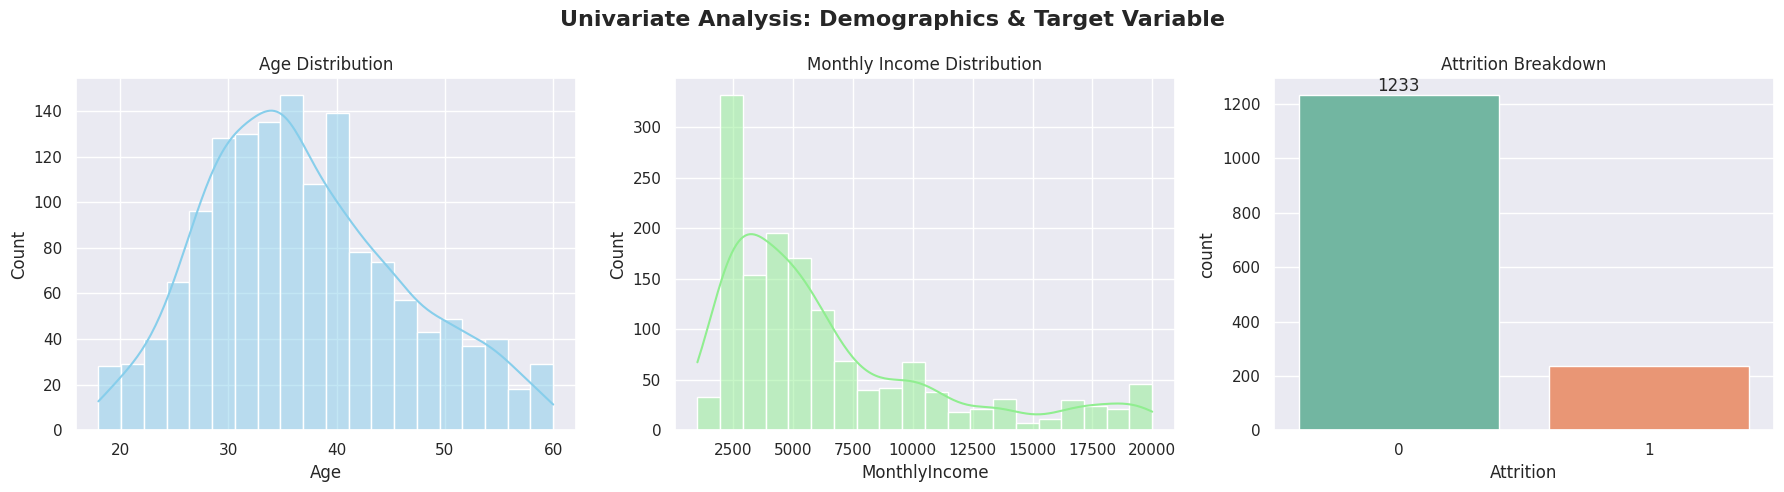

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Univariate Analysis: Demographics & Target Variable', fontsize=16, fontweight='bold')

# Plot A: Age Distribution
sns.histplot(df['Age'], bins=20, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Age Distribution')

# Plot B: Monthly Income Distribution
sns.histplot(df['MonthlyIncome'], bins=20, kde=True, ax=axes[1], color='lightgreen')
axes[1].set_title('Monthly Income Distribution')

# Plot C: Attrition Count (Our Target Variable)
sns.countplot(data=df, x='Attrition', hue='Attrition', legend=False, palette='Set2', ax=axes[2])
axes[2].set_title('Attrition Breakdown')
axes[2].bar_label(axes[2].containers[0])

plt.tight_layout()
plt.show()

In [31]:
# Map OverTime 'Yes' to 1 and 'No' to 0
df['OverTime_Num'] = df['OverTime'].apply(lambda x: 1 if x == 'Yes' else 0)

travel_map = {'Non-Travel': 0, 'Travel_Rarely': 1, 'Travel_Frequently': 2}
df['Travel_Num'] = df['BusinessTravel'].map(travel_map)

# Calculate Burnout Risk Score
df['BurnoutRiskScore'] = df['OverTime_Num'] + (5 - df['WorkLifeBalance'])

# Let's also make sure EngagementIndex is there just in case!
df['EngagementIndex'] = (df['JobInvolvement'] + df['JobSatisfaction']) / 2

In [32]:
# Satisfaction Stability Score (Consistency across dimensions)
satisfaction_cols = ['EnvironmentSatisfaction', 'JobSatisfaction', 'RelationshipSatisfaction']
df['SatisfactionStability'] = df[satisfaction_cols].var(axis=1)

# Workload Stress Indicator (Travel + Overtime intensity)
df['WorkloadStress'] = df['Travel_Num'] + df['OverTime_Num']

/tmp/ipykernel_3973/1608554842.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Attrition', y='BurnoutRiskScore', palette='pastel', ax=axes[0])
/tmp/ipykernel_3973/1608554842.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Department', y='EngagementIndex', palette='muted', ax=axes[1], inner='quartile')


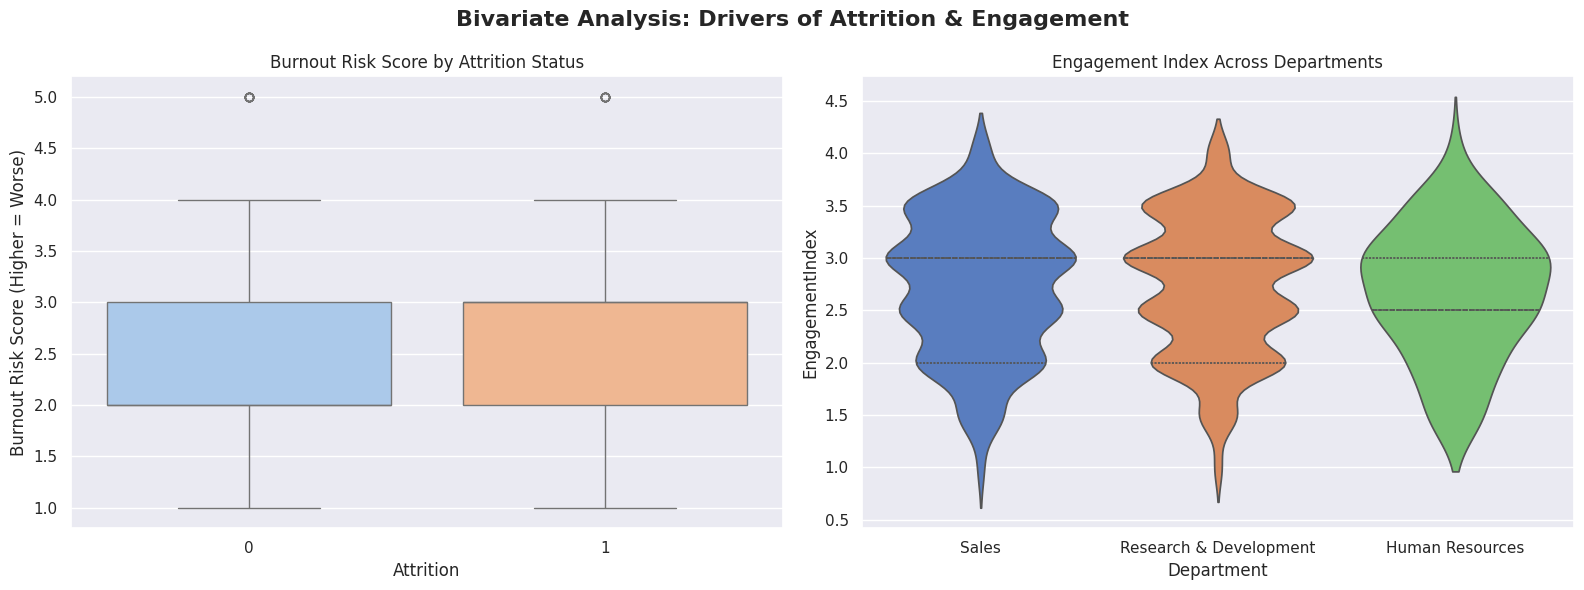

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Bivariate Analysis: Drivers of Attrition & Engagement', fontsize=16, fontweight='bold')

# Plot Burnout Risk Score vs Attrition
sns.boxplot(data=df, x='Attrition', y='BurnoutRiskScore', palette='pastel', ax=axes[0])
axes[0].set_title('Burnout Risk Score by Attrition Status')
axes[0].set_ylabel('Burnout Risk Score (Higher = Worse)')

# Plot Engagement Index by Department
sns.violinplot(data=df, x='Department', y='EngagementIndex', palette='muted', ax=axes[1], inner='quartile')
axes[1].set_title('Engagement Index Across Departments')

plt.tight_layout()
plt.show()

/tmp/ipykernel_3973/132019048.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='JobRole', y='EngagementIndex', hue='Attrition', palette='coolwarm', ci=None)


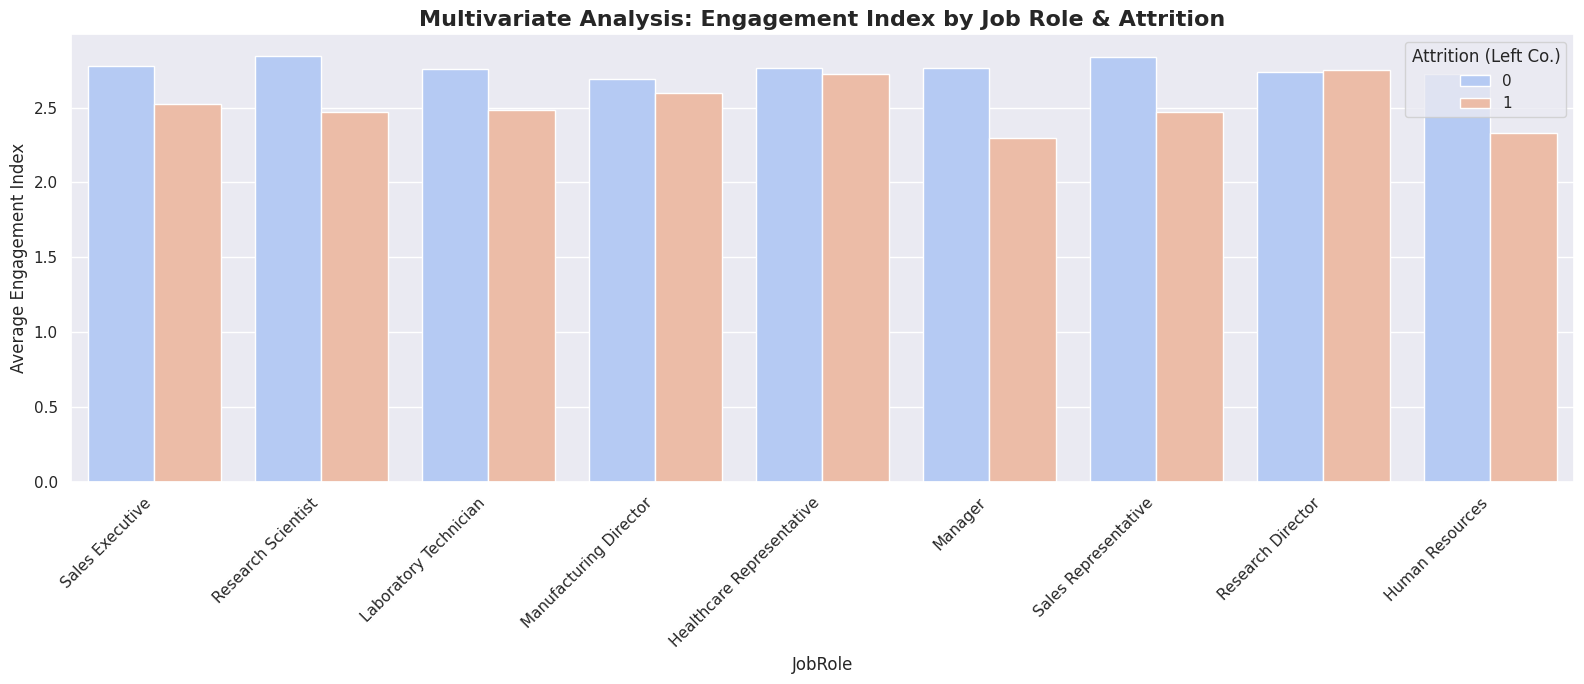

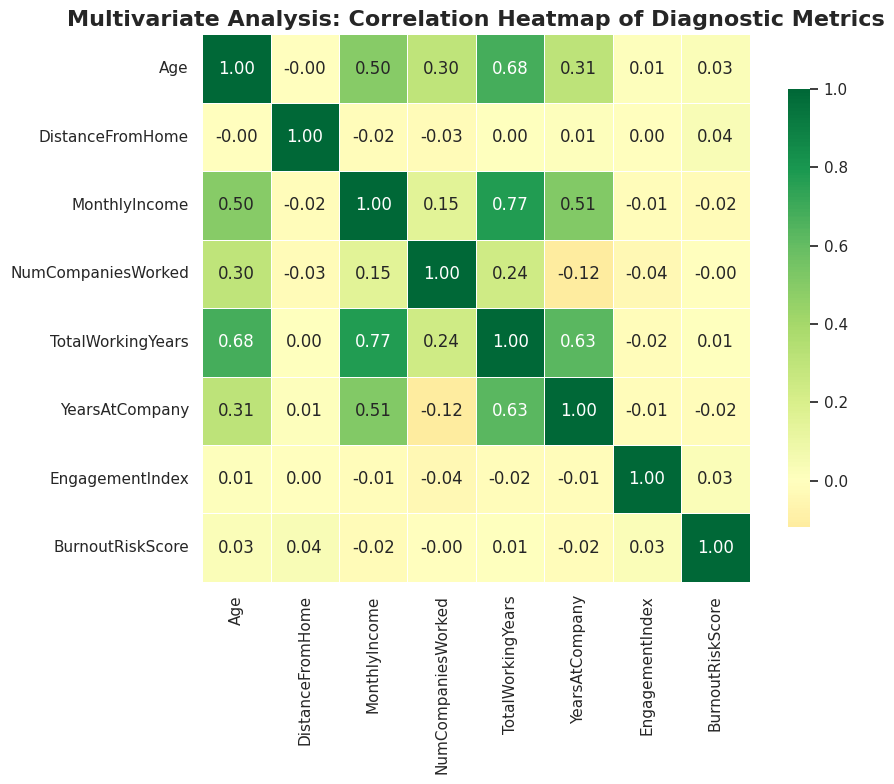

In [34]:
# Plot Engagement by Job Role, split by Attrition
plt.figure(figsize=(16, 7))
sns.barplot(data=df, x='JobRole', y='EngagementIndex', hue='Attrition', palette='coolwarm', ci=None)
plt.title('Multivariate Analysis: Engagement Index by Job Role & Attrition', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Attrition (Left Co.)', loc='upper right')
plt.ylabel('Average Engagement Index')
plt.tight_layout()
plt.show()

# Plot Correlation Heatmap for Key Metrics
plt.figure(figsize=(10, 8))

corr_cols = ['Age', 'DistanceFromHome', 'MonthlyIncome', 'NumCompaniesWorked',
             'TotalWorkingYears', 'YearsAtCompany', 'EngagementIndex', 'BurnoutRiskScore']
corr_matrix = df[corr_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', center=0, fmt='.2f', square=True,
            cbar_kws={"shrink": .8}, linewidths=0.5)
plt.title('Multivariate Analysis: Correlation Heatmap of Diagnostic Metrics', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [35]:
# Save the engineered dataset for the dashboard
df.to_csv('Palo_Alto_Cleaned.csv', index=False)